<a href="https://colab.research.google.com/github/lauratpaes/Anna-Clara-_-Laura_-Lavinia/blob/main/seminario1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Seminário 1 - 02/09

Anna Clara Belmiro Tonial - 17097091

Laura Tavares Paes - 17097601

Lavínia Ramos Lourenço - 17081100

#Estudo de aves: o tamanho relativo da asa dos pássaros possui associação com o comportamento migratório?

Fonte de dados: AVONET: morphological, ecological and geographical data for all birds (Tobias et al 2022 Ecology Letters doi: https://doi.org/10.111/ele.13898).

#Importação de dados

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = pd.read_excel ("seminário1.xlsx")
df.head (6)

,Species3,Family3,Order3,Total.individuals,Female,Male,Unknown,Complete.measures,Beak.Length_Culmen,Beak.Length_Nares,Beak.Width,Beak.Depth,Tarsus.Length,Wing.Length,Kipps.Distance,Secondary1,Hand-Wing.Index,Tail.Length,Mass,Mass.Source,Mass.Refs.Other,Inference,Traits.inferred,Reference.species,Habitat,Habitat.Density,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size,Species.Status
0,Abeillia abeillei,Trochilidae,Apodiformes,5,2,3,0,4,13.0,9.5,1.2,1.7,6.3,47.0,30.5,15.5,66.3,29.4,2.70,Dunning,NaN,NO,NaN,NaN,Forest,2.0,1.0,Herbivore,Nectarivore,Aerial,12.78,19.77,15.29,-89.792123,144610.40,Extant
1,Abroscopus albogularis,Sylviidae,Passeriformes,5,2,3,0,4,9.0,4.9,2.7,2.3,15.3,43.4,5.7,37.3,13.3,38.7,4.84,Dunning,NaN,NO,NaN,NaN,Forest,1.0,1.0,Carnivore,Invertivore,Insessorial,14.97,31.56,24.78,105.573934,1704650.60,Extant
2,Abroscopus schisticeps,Sylviidae,Passeriformes,4,3,1,0,4,9.0,4.7,2.6,2.3,16.5,47.1,7.6,39.5,16.1,47.5,4.70,Dunning,NaN,NO,NaN,NaN,Forest,1.0,1.0,Carnivore,Invertivore,Insessorial,20.19,31.12,26.70,95.584554,909217.05,Extant
3,Abroscopus superciliaris,Sylviidae,Passeriformes,5,2,3,0,4,12.3,7.4,3.1,2.8,16.6,51.2,6.5,44.5,12.7,42.4,6.48,Dunning,NaN,NO,NaN,NaN,Shrubland,1.0,1.0,Carnivore,Invertivore,Insessorial,-8.11,28.81,9.89,105.198587,2493437.47,Extant
4,Aburria aburri,Cracidae,Galliformes,12,6,6,0,4,37.1,16.6,9.3,10.2,65.8,337.2,52.5,283.1,15.7,290.4,1405.08,Dunning,NaN,NO,NaN,NaN,Forest,1.0,1.0,Herbivore,Frugivore,Insessorial,-13.43,11.15,-2.79,-75.233396,139314.36,Extant
5,Acanthagenys rufogularis,Meliphagidae,Passeriformes,17,5,12,0,4,25.7,11.3,3.7,5.0,25.1,111.1,25.0,82.8,23.2,111.4,47.80,Dunning,NaN,NO,NaN,NaN,Shrubland,2.0,1.0,Herbivore,Omnivore,Insessorial,-38.86,-16.14,-27.10,133.984452,5976565.20,Extant


#Sobre os dados e variáveis

A base de dados utilizada possui 36 colunas de variáveis,sendo uma grande quantidade de informações morfológicas de aves.

Para nosso trabalho, selecionamos 3 variáveis conforme nossa pergunta biológica:"há associação entre o tamanho relativo das asas e o comportamento migratório?". Assim, usamos a variável quantitativa contínua "massa", dada em gramas, a variável quantitativa contínua "comprimento da asa", dada em milímetros, e a variável qualitativa ordinal "migração", dada em uma escala de 1 a 3, em que 1 representa sem migração, 2 representa migração parcial a curtas distâncias e 3 representa migração total a longas distâncias.

O tamanho relativo das asas foi preferido em detrimento do comprimento real das asas para não estabelecer relações com base em valores biologicamente óbvios, já que uma ave grande certamente apresentará uma asa maior que uma ave de menor porte, e, em análise estatística, seria traduzido como que todas as aves de grande porte são migratórias, o que é uma conclusão incorreta.

In [ ]:
df['Wing_Mass_Ratio'] = df['Wing.Length'] / df['Mass']
dados_regressao = df[["Migration", "Wing_Mass_Ratio"]].dropna()

x_reg = dados_regressao["Migration"]
y_reg = dados_regressao["Wing_Mass_Ratio"]

print("Número de observações utilizadas:", len(dados_regressao))

Número de observações utilizadas: 9973


#Proporção categorias migratórias
A fim de facilitar a visão panorâmica da quantia total de estilos migratórios, foi produzido um gráfico de pizza.

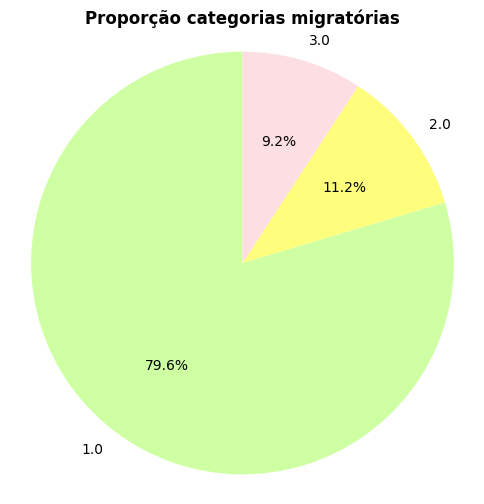

In [ ]:
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()

contagem = df['Migration'].value_counts()

minhas_cores = ['#ceffa2', '#fefe7c', '#fddee2']

plt.figure(figsize=(6, 6))
plt.pie(contagem, labels=contagem.index, autopct='%1.1f%%', startangle=90, colors=minhas_cores)
plt.title('Proporção categorias migratórias', fontsize=12, fontweight='bold')
plt.axis('equal')

plt.show()

In [ ]:
from google.colab import files
files.download('scatter_plot_tamanho_relativo_asas_migracao.png')

#Tamanho relativo da asa das aves

Para gerar nossa variável contínua central, dividiremos o comprimento da asa pela massa corporal de cada espécie observada, que produzirá uma tabela com dados em mm/g, ou seja, quantos milímetros de asa existem para cada grama de massa corporal.

In [ ]:
df['Wing_Mass_Ratio'] = df['Wing.Length'] / df['Mass']
selected_columns = df[['Species3', 'Wing.Length', 'Mass','Migration', 'Wing_Mass_Ratio']]
display(selected_columns.head(6))

,Species3,Wing.Length,Mass,Migration,Wing_Mass_Ratio
0,Abeillia abeillei,47.0,2.70,1.0,17.407407
1,Abroscopus albogularis,43.4,4.84,1.0,8.966942
2,Abroscopus schisticeps,47.1,4.70,1.0,10.021277
3,Abroscopus superciliaris,51.2,6.48,1.0,7.901235
4,Aburria aburri,337.2,1405.08,1.0,0.239986
5,Acanthagenys rufogularis,111.1,47.80,1.0,2.324268


#Medidas descritivas

In [ ]:
mean_wing_mass_ratio = df['Wing_Mass_Ratio'].mean()
print(f"A média de 'Wing_Mass_Ratio' é: {mean_wing_mass_ratio:.6f}")

A média de 'Wing_Mass_Ratio' é: 3.191188


In [ ]:
mode_wing_mass_ratio = df['Wing_Mass_Ratio'].mode()
if not mode_wing_mass_ratio.empty:
    print(f"A(s) moda(s) de 'Wing_Mass_Ratio' é (são):\n{mode_wing_mass_ratio.to_string(index=False)}")
else:
    print("Não foi encontrada uma moda clara para 'Wing_Mass_Ratio' (todos os valores são únicos ou não há valores suficientes).")

A(s) moda(s) de 'Wing_Mass_Ratio' é (são):
5.0


In [ ]:
median_wing_mass_ratio = df['Wing_Mass_Ratio'].median()
print(f"A mediana de 'Wing_Mass_Ratio' é: {median_wing_mass_ratio:.6f}")

A mediana de 'Wing_Mass_Ratio' é: 2.612000


In [ ]:
count_mode_wing_mass_ratio = df[df['Wing_Mass_Ratio'] == 5.0].shape[0]
print(f"A moda 5.0 aparece {count_mode_wing_mass_ratio} vezes na coluna 'Wing_Mass_Ratio'.")

A moda 5.0 aparece 10 vezes na coluna 'Wing_Mass_Ratio'.


In [ ]:
mean_wing_length = df['Wing.Length'].mean()
print(f"A média de 'Wing.Length' é: {mean_wing_length:.2f}")

A média de 'Wing.Length' é: 126.34


In [ ]:
mode_wing_length = df['Wing.Length'].mode()
if not mode_wing_length.empty:
    print(f"A(s) moda(s) de 'Wing.Length' é (são):\n{mode_wing_length.to_string(index=False)}")
else:
    print("Não foi encontrada uma moda clara para 'Wing.Length' (todos os valores são únicos ou não há valores suficientes).")

A(s) moda(s) de 'Wing.Length' é (são):
52.0


In [ ]:
count_mode_wing_length = df[df['Wing.Length'] == 52.0].shape[0]
print(f"O valor 52.0 aparece {count_mode_wing_length} vezes na coluna 'Wing.Length'.")

O valor 52.0 aparece 27 vezes na coluna 'Wing.Length'.


In [ ]:
median_wing_length = df['Wing.Length'].median()
print(f"A mediana de 'Wing.Length' é: {median_wing_length:.2f}")

A mediana de 'Wing.Length' é: 92.10


In [ ]:
mean_mass = df['Mass'].mean()
print(f"A média de 'Mass' é: {mean_mass:.2f}")

A média de 'Mass' é: 268.92


In [ ]:
mode_mass = df['Mass'].mode()
if not mode_mass.empty:
    print(f"A(s) moda(s) de 'Mass' é (são):\n{mode_mass.to_string(index=False)}")
else:
    print("Não foi encontrada uma moda clara para 'Mass' (todos os valores são únicos ou não há valores suficientes).")

A(s) moda(s) de 'Mass' é (são):
11.0


In [ ]:
count_mode_mass = df[df['Mass'] == 11.0].shape[0]
print(f"O valor 11.0 aparece {count_mode_mass} vezes na coluna 'Mass'.")

O valor 11.0 aparece 54 vezes na coluna 'Mass'.


In [ ]:
median_mass = df['Mass'].median()
print(f"A mediana de 'Mass' é: {median_mass:.2f}")

A mediana de 'Mass' é: 35.50


In [ ]:
mode_migration = df['Migration'].mode()
if not mode_migration.empty:
    print(f"A(s) moda(s) de 'Migration' é (são):\n{mode_migration.to_string(index=False)}")
else:
    print("Não foi encontrada uma moda clara para 'Migration' (todos os valores são únicos ou não há valores suficientes).")

A(s) moda(s) de 'Migration' é (são):
1.0


In [ ]:
count_mode_migration = df[df['Migration'] == 1.0].shape[0]
print(f"O valor 1.0 aparece {count_mode_migration} vezes na coluna 'Migration'.")

O valor 1.0 aparece 7941 vezes na coluna 'Migration'.


###Tendência central

- Para a variável "tamanho relativo das asas", verifica-se que a média é de 3,191188 mm/g, moda de 5 mm/g, valor que se repete 10 vezes dentro das 9.993 colunas, e mediana de 2,612000 mm/g.

- Para a variável base "comprimento da asa", obtém-se média de 126,34mm, moda de 52mm, que se repete 27 vezes na série, e mediana de 92,10mm.

- Para a variável base "massa", a média é de 268,92g, a moda é de 11g, valor que se repete 54 vezes, e a mediana é de 35,50g.

- Para a variável "migração", a moda é 1, número que representa aves não migratórias, sendo a maioria dos dados (7941 repetições).

###Análise da variável "tamanho relativo das asas"

####Assimetria à direita
Os dados do tamanho relativo das asas apresentam distribuição com assimetria à direita em um histograma, situação que revela que a maioria das aves possuem baixo tamanho relativo das asas e poucas demonstram valores altos.

####Medidas descritivas

- Média: 3,191188 mm/g
- Mediana: 2,612000 mm/g
- Desvio-padrão: 2,70 mm/g
- Mínimo: 0,000043 mm/g
- Máximo: 21,210526 mm/g
- Primeiro quartil: 1,189325 mm/g
- Terceiro quartil: 4,504348 mm/g
- Intervalo interquatílico: 3.315023 mm/g
- Coeficiente de variação: 84,63%

*Para lembrar: o desvio-padrão é a distância média que cada valor individual está da média, ou seja, é uma medida que revela o quão espalhados os valores estão em torno da média. Na nossa amostra, o desvio é alto se o comparar com a média, o que significa que há grande dispersão de dados. Além disso, o coeficiente de variação confirma essa heterogeneidade por apresentar um valor muito alto.

In [ ]:
wing_mass_ratio_stats = df['Wing_Mass_Ratio'].describe()
print(f"Mínimo: {wing_mass_ratio_stats['min']:.6f}")
print(f"Primeiro Quartil (Q1): {wing_mass_ratio_stats['25%']:.6f}")
print(f"Terceiro Quartil (Q3): {wing_mass_ratio_stats['75%']:.6f}")
print(f"Máximo: {wing_mass_ratio_stats['max']:.6f}")

Mínimo: 0.000043
Primeiro Quartil (Q1): 1.189325
Terceiro Quartil (Q3): 4.504348
Máximo: 21.210526


In [ ]:
q1_wing_mass_ratio = wing_mass_ratio_stats['25%']
q3_wing_mass_ratio = wing_mass_ratio_stats['75%']
iqr_wing_mass_ratio = q3_wing_mass_ratio - q1_wing_mass_ratio
print(f"O Intervalo Interquartil (IQR) de 'Wing_Mass_Ratio' é: {iqr_wing_mass_ratio:.6f}")

O Intervalo Interquartil (IQR) de 'Wing_Mass_Ratio' é: 3.315023


In [ ]:
coefficient_of_variation = (df['Wing_Mass_Ratio'].std() / df['Wing_Mass_Ratio'].mean()) * 100
print(f"O coeficiente de variação de 'Wing_Mass_Ratio' é: {coefficient_of_variation:.2f}%")

O coeficiente de variação de 'Wing_Mass_Ratio' é: 84.63%


In [ ]:
std_wing_mass_ratio = df['Wing_Mass_Ratio'].std()
print(f"O desvio padrão de 'Wing_Mass_Ratio' é: {std_wing_mass_ratio:.2f}")

O desvio padrão de 'Wing_Mass_Ratio' é: 2.70


###Histograma do tamanho relativo das asas

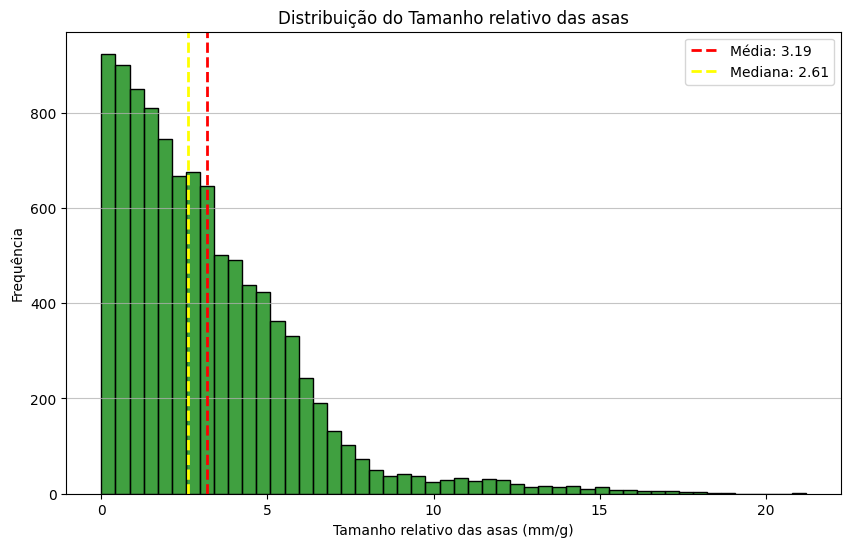

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Wing_Mass_Ratio'], bins=50, kde=False, color='green')
plt.title('Distribuição do Tamanho relativo das asas')
plt.xlabel('Tamanho relativo das asas (mm/g)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.axvline(mean_wing_mass_ratio, color='red', linestyle='dashed', linewidth=2, label=f'Média: {mean_wing_mass_ratio:.2f}')
plt.axvline(median_wing_mass_ratio, color='yellow', linestyle='dashed', linewidth=2, label=f'Mediana: {median_wing_mass_ratio:.2f}')

plt.legend()
plt.savefig('histograma_tamanho_relativo_das_asas.png')
plt.show()

In [ ]:
from google.colab import files
files.download('histograma_tamanho_relativo_das_asas.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

####Discussão

O histograma da variável mostra uma longa causa à direita, ou seja, possui assimetria positiva. Este fator nos diz que há uma grande concentração dos dados em menor valor, com valores maiores em menor frequência. Além disso, podemos ver também que a média é maior que a mediana, situação que confirma a assimetria positiva.

Com base nessa distribuição, é esperado que a maioria das aves computadas sejam não migratórias, já que há uma concentração de tamanhos menores. Logo, aves migratórias deveriam se apresentar em menor número devido a assimetria à direita, a qual mostra menor frequência de tamanhos relativos maiores.

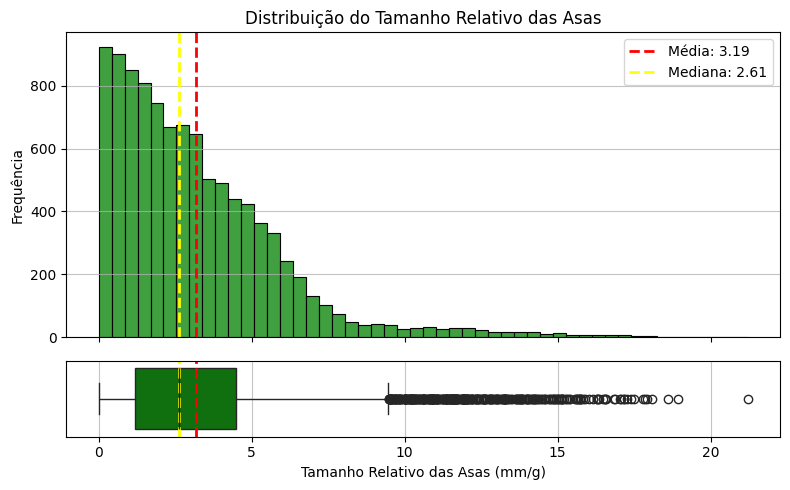

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax_hist, ax_box) = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={'height_ratios': [0.8, 0.2]})

sns.histplot(df['Wing_Mass_Ratio'], bins=50, kde=False, color='green', ax=ax_hist)
ax_hist.set_title('Distribuição do Tamanho Relativo das Asas')
ax_hist.set_ylabel('Frequência')
ax_hist.grid(axis='y', alpha=0.75)
ax_hist.axvline(mean_wing_mass_ratio, color='red', linestyle='dashed', linewidth=2, label=f'Média: {mean_wing_mass_ratio:.2f}')
ax_hist.axvline(median_wing_mass_ratio, color='yellow', linestyle='dashed', linewidth=2, label=f'Mediana: {median_wing_mass_ratio:.2f}')
ax_hist.legend()

sns.boxplot(x=df['Wing_Mass_Ratio'], color='green', ax=ax_box)
ax_box.set_xlabel('Tamanho Relativo das Asas (mm/g)')
ax_box.grid(axis='x', alpha=0.75)
ax_box.axvline(mean_wing_mass_ratio, color='red', linestyle='dashed', linewidth=2)
ax_box.axvline(median_wing_mass_ratio, color='yellow', linestyle='dashed', linewidth=2)
ax_box.set_yticks([])

plt.tight_layout()
plt.savefig('distribuição_tamanho_relativo_das_asas.png')
plt.show()

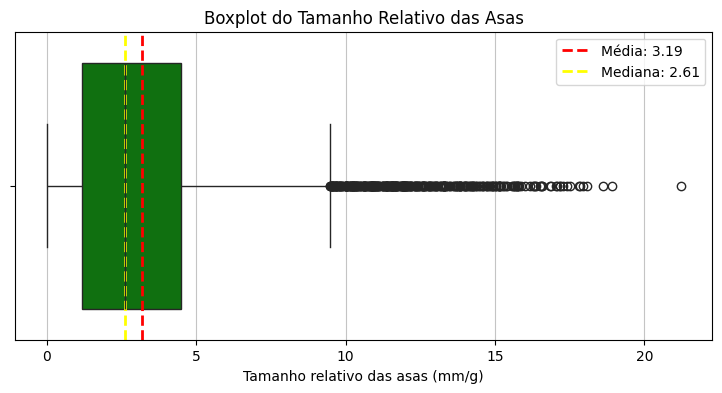

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 4))
sns.boxplot(x=df['Wing_Mass_Ratio'], color='green')
plt.title('Boxplot do Tamanho Relativo das Asas')
plt.xlabel('Tamanho relativo das asas (mm/g)')
plt.grid(axis='x', alpha=0.75)
plt.axvline(mean_wing_mass_ratio, color='red', linestyle='dashed', linewidth=2, label=f'Média: {mean_wing_mass_ratio:.2f}')
plt.axvline(median_wing_mass_ratio, color='yellow', linestyle='dashed', linewidth=2, label=f'Mediana: {median_wing_mass_ratio:.2f}')
plt.legend()
plt.show()

####Discussão

No boxplot, a ideia de concentração de dados em menores valores se confirma e podemos visualizar os outliners. Perceba que a maioria dos dados estão concentrados na faixa abaixo de 10 mm/g, enquantos valores superiores a isso são atípicos.

50% dos valores estão na faixa de aproximadamente 1,19 a 4,50 mm/g, enquanto 75% dos valores possuem valor até 4,50 mm/g.

Seguindo o mesmo raciocínio do histograma, é esperado então a maioria das aves sejam não migratórias.

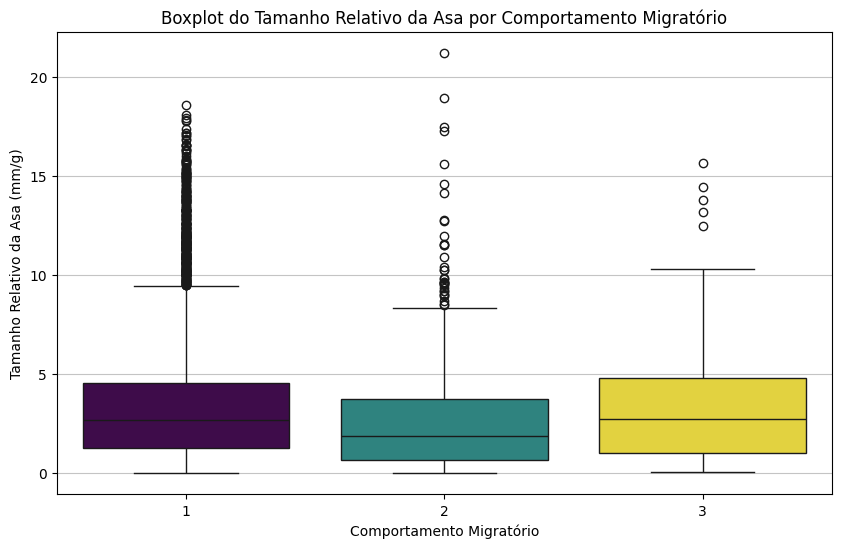

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Migration', y='Wing_Mass_Ratio', data=df, palette='viridis', hue='Migration', legend=False)
plt.title('Boxplot do Tamanho Relativo da Asa por Comportamento Migratório')
plt.xlabel('Comportamento Migratório')
plt.ylabel('Tamanho Relativo da Asa (mm/g)')
plt.grid(axis='y', alpha=0.75)
plt.xticks([0, 1, 2], [1, 2, 3])
plt.savefig('boxplot_tamanho_relativo_das_asas_por_comportamento_mgratorio.png')
plt.show()

In [ ]:
import google.colab
google.colab.files.download('boxplot_tamanho_relativo_das_asas_por_comportamento_mgratorio.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Gráfico de dispersão





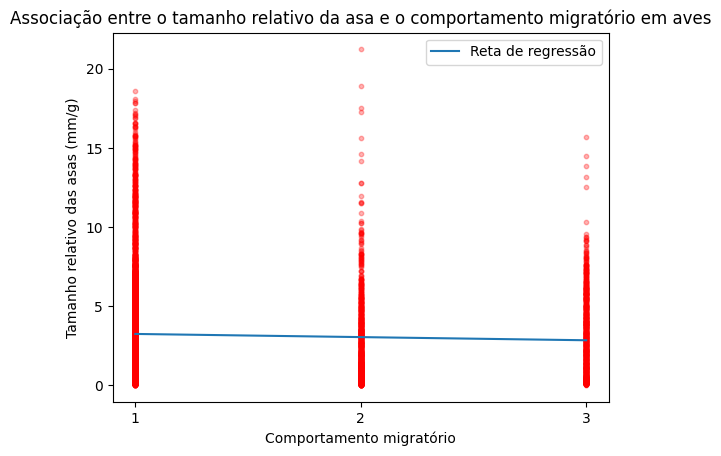

In [ ]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

df['Wing_Mass_Ratio'] = df['Wing.Length'] / df['Mass']
dados_regressao = df[["Migration", "Wing_Mass_Ratio"]].dropna()
x_reg = dados_regressao["Migration"]
y_reg = dados_regressao["Wing_Mass_Ratio"]
regressao = linregress(x_reg, y_reg)
plt.xticks([1, 2, 3])
x_reta = np.array([1,2,3])
y_reta = regressao.intercept + regressao.slope * x_reta
plt.plot (x_reta, y_reta, label="Reta de regressão")
x = df["Migration"]
y = df["Wing_Mass_Ratio"]
plt.scatter(x, y, color="red", s=10, alpha=0.3)
plt.title("Associação entre o tamanho relativo da asa e o comportamento migratório em aves")
plt.ylabel("Tamanho relativo das asas (mm/g)")
plt.xlabel("Comportamento migratório")
plt.xticks([1, 2, 3])
plt.legend()
plt.savefig('scatter_plot_tamanho_relativo_asas_migracao.png')
plt.show()

In [ ]:
print("intercepto", regressao.intercept)
print("Coeficiente angular:",regressao.slope)
x_reta = np.array([1,2,3])
y_reta = regressao.intercept + regressao.slope * x_reta
print("X:", x_reta)
print("Y previsto:", y_reta)

intercepto 3.4496883168675523
Coeficiente angular: -0.19959629093087547
X: [1 2 3]
Y previsto: [3.25009203 3.05049574 2.85089944]


In [ ]:
from scipy.stats import linregress

regressao = linregress(x_reg, y_reg)

print("Intercepto (β₀):", regressao.intercept)
print("Coeficiente angular (β₁):", regressao.slope)

Intercepto (β₀): 3.4496883168675523
Coeficiente angular (β₁): -0.19959629093087547


In [ ]:
from scipy.stats import pearsonr

r, p = pearsonr(x_reg, y_reg)

print("Coeficiente de correlação de Pearson (r):", r)
print("p-valor:", p)

Coeficiente de correlação de Pearson (r): -0.04627797900295926
p-valor: 3.774208860138678e-06


####Discussão

A regressão linear simples é uma técnica utilizada para quantificar a associação entre duas variáveis numéricas, sendo uma independente (x) e outra dependente (y). Neste caso, x corresponde ao comportamento migratório e y ao tamanho relativo das asas (mm/g).

A equação de regressão linear é dada pela fórmula geral: y = a + bx, em que “a” representa o ponto em que a reta intercepta o eixo y e “b” indica o coeficiente angular (inclinação da reta). Com os valores analisados, temos: a = 3,4497 e b = −0,1996, resultando na equação:

y = 3,4497 − 0,1996X

O coeficiente de correlação de Pearson apresentou valor de r = −0,0463, indicando uma correlação linear negativa muito fraca entre as variáveis. Apesar do p-valor ser significativo (p < 0,001), a proximidade do coeficiente de zero mostra que a associação linear observada é pouco expressiva.


